# Regressão Logística - Machine Learning #1

**O que é?**: Regressão Logística é um algoritimo supervisionado de classificação. Apesar do nome "regressão", ela é usada para prever valores binarios (na maioria dos casos).

**Como funciona?**: Ela nos retorna a probabilidade de uma classe ser 1. A partir disso, a regressão firma um treshold para classificar 1. O modelo não “retorna diretamente 0 ou 1”. Primeiro ele calcula a probabilidade; depois o threshold transforma essa probabilidade em uma classe.

**Exemplo Treshold 0.6**: Eu tenho um modelo para classificar se eu tenho Laranja(0) ou Maça(1), meu modelo fala que tem 59% de chance de ser Maça(1) LOGO minha previsão é 0, porque meu treshold é 60%, eu precisava no minimo que fosse 61.

**Combinação Linear**: z = B0 + B1.x1 + B2.x2 ... + Bn.xn
- B: são os parametros/pesos/theta.
- x: são as features, colunas, variaveis.
- B0: o valor que o modelo prevê para y quando todas as features x valem zero.

**Função de Ativação**: z pode ser qualquer valor, mas nós precisamos de uma probabilidade. Então aplicamos uma função de ativação para obter esse valor. Neste caso vamos usar a *`sigmoid`*.

**sigmoid**:  a(z) = 1 / (1 + e^-z)
- e: numero de Euler, que é aproximadamente 2,718
- -z: inverte o sinal
- z: o valor resultado da Combinação Linear


## Parametros de LogisticRegression
- fit_intercept (bool): Decide se o modelo deve calcular o intercepreto de B0
  - Caso ele seja False, a função é obrigado a passar pelo ponto de origem (0,0) no plano cartesiano.
- copy_X (bool): Define se o X será copiado antes do treinamento
- n_jobs (int ou None): Número de CPUs usadas; geralmente não faz diferença para problemas pequenos
- positive (bool): Se True, força todos os coeficientes a serem positivos ou zero

---
## Desafio

Utilize o dataset de risco de doenças de coração abaixo e treine um modelo de regressão logística para prever o risco.

**Regras**
- Não copie e cole código diretamente da IA, tente reescrever mesmo que o código seja extenso.
- Foque em aprender os conceitos, como operam e como manipular os dados para modelagem.
- Aplique um K-FOLD para validação cruzada.
- Mostre o relatório de métricas ao final
- Reporte os resultados do modelo com suas palavras, e conclua se você colocaria este modelo em produção ou não.

### 0. Importação do Dataset

In [1]:
import kagglehub
import pandas as pd
pd.set_option('display.max_columns', None)
# Download latest version
path = kagglehub.dataset_download("uditjain13/heart-disease-risk-2026")

print("Path to dataset files:", path)

df = pd.read_csv(f'{path}/heart_disease_risk_2026.csv')
df.info()

Path to dataset files: /home/leo/.cache/kagglehub/datasets/uditjain13/heart-disease-risk-2026/versions/3
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   patient_id                 9000 non-null   int64  
 1   age                        9000 non-null   int64  
 2   sex                        9000 non-null   object 
 3   resting_bp_systolic        9000 non-null   int64  
 4   resting_bp_diastolic       9000 non-null   int64  
 5   cholesterol_total          9000 non-null   int64  
 6   hdl                        9000 non-null   int64  
 7   ldl                        9000 non-null   int64  
 8   triglycerides              9000 non-null   int64  
 9   fasting_blood_sugar        9000 non-null   int64  
 10  hba1c                      9000 non-null   float64
 11  bmi                        9000 non-null   float64
 12 

In [2]:
df['wearable_owner'].value_counts()

wearable_owner
False    5015
True     3985
Name: count, dtype: int64

### 1. Análise Exploratória

In [3]:
import matplotlib.pyplot as plt

/home/leo/.local/lib/python3.13/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [4]:
df.to_parquet('heart_disease_risk_dataset.parquet', index= False)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   patient_id                 9000 non-null   int64  
 1   age                        9000 non-null   int64  
 2   sex                        9000 non-null   object 
 3   resting_bp_systolic        9000 non-null   int64  
 4   resting_bp_diastolic       9000 non-null   int64  
 5   cholesterol_total          9000 non-null   int64  
 6   hdl                        9000 non-null   int64  
 7   ldl                        9000 non-null   int64  
 8   triglycerides              9000 non-null   int64  
 9   fasting_blood_sugar        9000 non-null   int64  
 10  hba1c                      9000 non-null   float64
 11  bmi                        9000 non-null   float64
 12  resting_heart_rate         9000 non-null   int64  
 13  max_heart_rate_achieved    9000 non-null   int64

In [6]:
df['has_heart_disease'].value_counts(normalize = True)

has_heart_disease
0    0.697
1    0.303
Name: proportion, dtype: float64

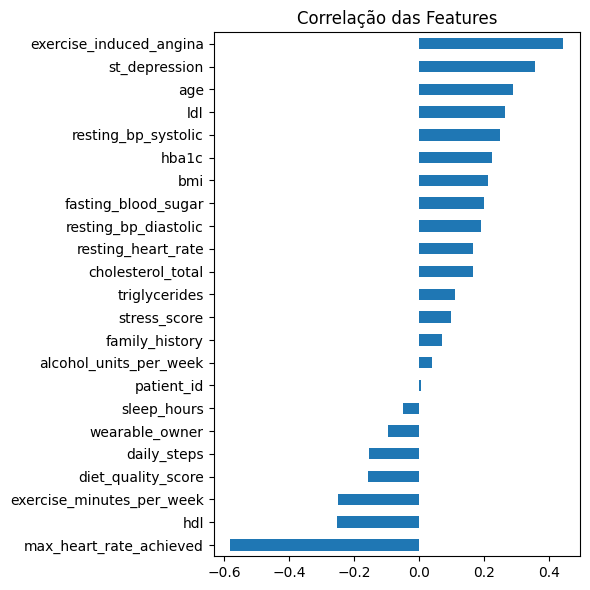

In [32]:
corr_target = (
    df.select_dtypes(include=['int64', 'float64'])
      .astype(float)
      .corr()['has_heart_disease']
      .drop('has_heart_disease')
      .sort_values()
)
corr_target.plot(kind='barh', figsize=(6, 6), title='Correlação das Features')
plt.tight_layout()
plt.show()

### 2. Pré-Processamento

In [8]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import make_column_transformer

In [9]:
colunas_bool = df.select_dtypes(include = 'bool')
colunas_bool = list(colunas_bool)

df[colunas_bool] = df[colunas_bool].astype(int)

In [10]:
X = df.drop(['has_heart_disease', 'patient_id'], axis= 1)
y = df['has_heart_disease']

In [11]:
colunas_str = X.select_dtypes(include = 'object')
colunas_str = list(colunas_str)

one_hot_encoder = make_column_transformer(
    (OneHotEncoder(drop = 'if_binary'), colunas_str),
    remainder='passthrough',
    sparse_threshold=0
)

scaler = StandardScaler()

In [12]:
colunas_X = X.columns
X = one_hot_encoder.fit_transform(X)

In [13]:
X = pd.DataFrame(X, columns=one_hot_encoder.get_feature_names_out())

In [14]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 30 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   onehotencoder__sex_Male                          9000 non-null   float64
 1   onehotencoder__chest_pain_type_Asymptomatic      9000 non-null   float64
 2   onehotencoder__chest_pain_type_Atypical Angina   9000 non-null   float64
 3   onehotencoder__chest_pain_type_Non-Anginal Pain  9000 non-null   float64
 4   onehotencoder__chest_pain_type_Typical Angina    9000 non-null   float64
 5   onehotencoder__smoker_status_Current             9000 non-null   float64
 6   onehotencoder__smoker_status_Former              9000 non-null   float64
 7   onehotencoder__smoker_status_Never               9000 non-null   float64
 8   remainder__age                                   9000 non-null   float64
 9   remainder__resting_bp_systolic

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X , y , test_size=0.25, stratify = y)
X_train_scaled, X_test_scaled = scaler.fit_transform(X_train), scaler.transform(X_test)

X_train_scaled , X_test_scaled = pd.DataFrame(X_train_scaled, columns = X_train.columns, index = X_train.index) , pd.DataFrame(X_test_scaled, columns = X_test.columns, index = X_test.index)

### 3. Modelagem (Regressão Logística)

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, RocCurveDisplay, precision_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

In [17]:
model_default = LogisticRegression()
model_scaled = LogisticRegression()

model_default.fit(X_train, y_train)
model_scaled.fit(X_train_scaled, y_train)

print("Score do modelo normal",model_default.score(X_train, y_train))
print("Score do modelo escalado",model_scaled.score(X_train_scaled, y_train))

Score do modelo normal 0.8386666666666667
Score do modelo escalado 0.9008888888888889


/home/leo/.local/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [18]:
print("Score Teste do modelo normal", model_default.score(X_test , y_test))
print("Score Teste do modelo escalado",model_scaled.score(X_test_scaled, y_test))

Score Teste do modelo normal 0.8297777777777777
Score Teste do modelo escalado 0.904


In [19]:
y_prev_default = model_default.predict(X_test)
y_prev_scaled = model_scaled.predict(X_test_scaled)

print("MODELO DEFAULT")
print(classification_report(y_test, y_prev_default))
print(120*"=")
print("MODELO ESCALADO")
print(classification_report(y_test, y_prev_scaled))

MODELO DEFAULT
              precision    recall  f1-score   support

           0       0.86      0.91      0.88      1568
           1       0.75      0.65      0.70       682

    accuracy                           0.83      2250
   macro avg       0.80      0.78      0.79      2250
weighted avg       0.83      0.83      0.83      2250

MODELO ESCALADO
              precision    recall  f1-score   support

           0       0.92      0.94      0.93      1568
           1       0.86      0.82      0.84       682

    accuracy                           0.90      2250
   macro avg       0.89      0.88      0.88      2250
weighted avg       0.90      0.90      0.90      2250



In [20]:
# teste para achar o coeficiente que melhora o resultado do modelo escaladp
for C in [0.001, 0.01, 0.1, 1, 10, 100]:

    model = LogisticRegression(C=C, max_iter=1000)
    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)

    print(f"\nC = {C}")
    print(classification_report(y_test, y_pred))


C = 0.001
              precision    recall  f1-score   support

           0       0.87      0.97      0.92      1568
           1       0.90      0.66      0.76       682

    accuracy                           0.88      2250
   macro avg       0.88      0.82      0.84      2250
weighted avg       0.88      0.88      0.87      2250


C = 0.01
              precision    recall  f1-score   support

           0       0.91      0.95      0.93      1568
           1       0.87      0.78      0.82       682

    accuracy                           0.90      2250
   macro avg       0.89      0.86      0.88      2250
weighted avg       0.90      0.90      0.90      2250


C = 0.1
              precision    recall  f1-score   support

           0       0.92      0.95      0.93      1568
           1       0.87      0.81      0.84       682

    accuracy                           0.90      2250
   macro avg       0.89      0.88      0.88      2250
weighted avg       0.90      0.90      0.90 

### 4. Análise dos resultados

Importancia das features para cada classe

In [21]:
import shap
import matplotlib.pyplot as plt

#SHAP < 0 → empurra a previsão para a classe negativa
#SHAP > 0 → empurra a previsão para a classe positiva
#Quanto mais distante de 0 → maior o impacto

Modelo Default

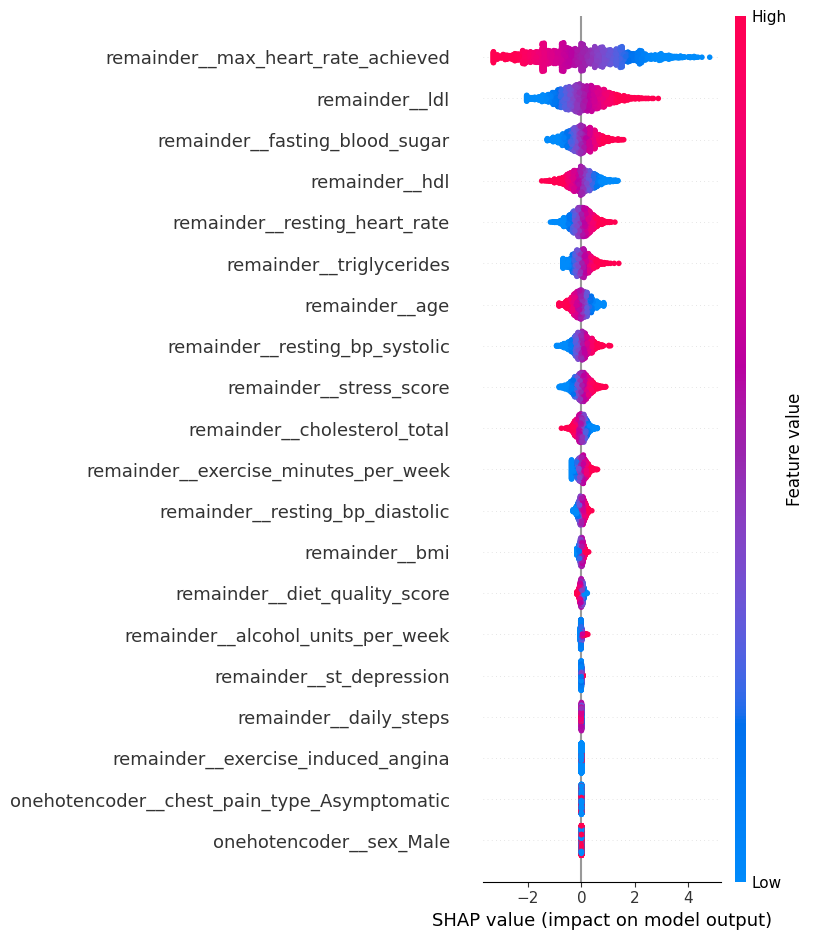

In [22]:
masker_default = shap.maskers.Independent(X_train, max_samples=len(X_train))
explainer = shap.LinearExplainer(model_default, masker_default)
shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test, feature_names=X.columns)

Modelo Scaled

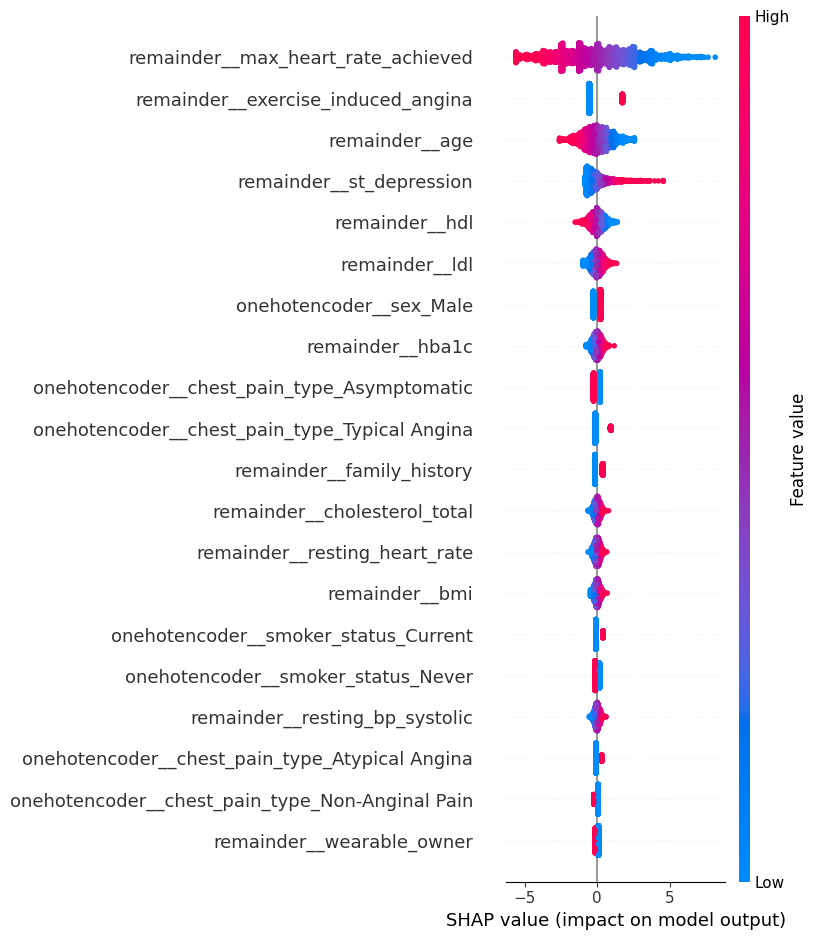

In [23]:
masker_scaled = shap.maskers.Independent(X_train_scaled, max_samples=len(X_train_scaled))
explainer = shap.LinearExplainer(model_scaled, masker_scaled)
shap_values = explainer(X_test_scaled)

shap.summary_plot(shap_values, X_test_scaled, feature_names=X.columns)

#SHAP < 0 → empurra a previsão para a classe negativa
#SHAP > 0 → empurra a previsão para a classe positiva
#Quanto mais distante de 0 → maior o impacto

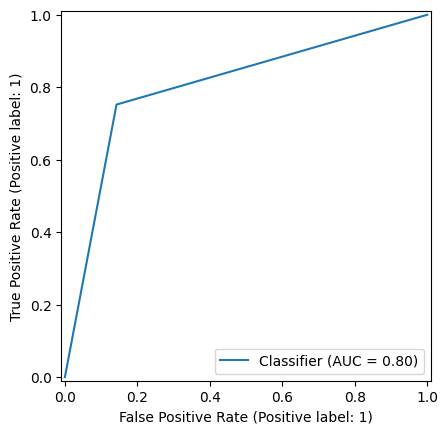

In [24]:
RocCurveDisplay.from_predictions(y_prev_default, y_test)

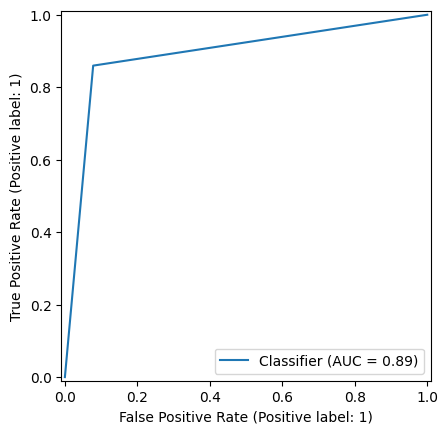

In [25]:
RocCurveDisplay.from_predictions(y_prev_scaled, y_test)

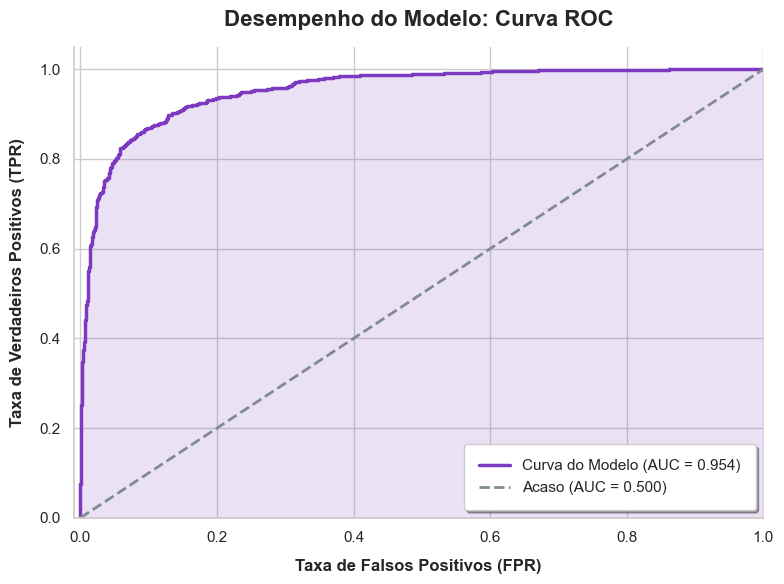

In [36]:
import seaborn as sns
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.metrics import roc_curve, auc

# Pegando as probabilidades da classe positiva
y_scores = model_scaled.predict_proba(X_test_scaled)[:, 1]

# ==========================================
# 2. Cálculo das Métricas ROC e AUC
# ==========================================
fpr, tpr, thresholds = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)

# ==========================================
# 3. Plotagem do Gráfico "Bonito"
# ==========================================
# Configura o estilo base do Seaborn para um visual mais limpo
sns.set_theme(style="whitegrid")

# Define o tamanho da figura
plt.figure(figsize=(8, 6))

# Cor principal da curva
cor_curva = '#7d3ac1' # Um roxo moderno e vibrante

# Plota a curva ROC com uma linha mais espessa (lw=2.5)
plt.plot(fpr, tpr, color=cor_curva, lw=2.5, 
         label=f'Curva do Modelo (AUC = {roc_auc:.3f})')

# Preenche a área sob a curva para dar destaque visual (O segredo da beleza)
plt.fill_between(fpr, tpr, color=cor_curva, alpha=0.15)

# Plota a linha de baseline (o modelo aleatório que tem AUC = 0.5)
plt.plot([0, 1], [0, 1], color='#7f8c8d', lw=2, linestyle='--', 
         label='Acaso (AUC = 0.500)')

# Customização de limites, textos e legendas
plt.xlim([-0.01, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos (FPR)', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)', fontsize=12, fontweight='bold', labelpad=10)
plt.title('Desempenho do Modelo: Curva ROC', fontsize=16, fontweight='bold', pad=15)

# Configura a legenda com uma leve sombra e borda arredondada
plt.legend(loc="lower right", fontsize=11, frameon=True, shadow=True, borderpad=1)

# Remove as bordas superior e direita (despine) para um visual minimalista
sns.despine()

# Ajusta o layout para nada ficar cortado
plt.tight_layout()

# Exibe o gráfico
plt.show()

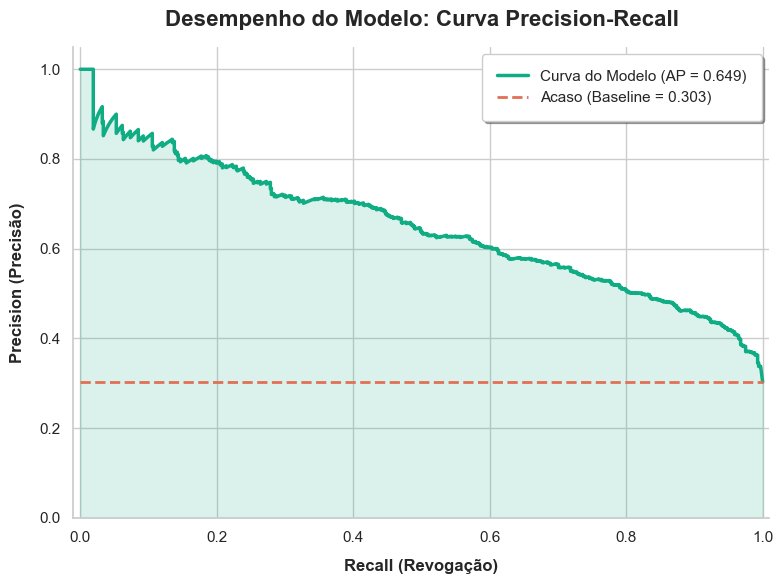

In [37]:
from sklearn.metrics import precision_recall_curve, average_precision_score

y_scores = model.predict_proba(X_test)[:, 1]

# ==========================================
# 2. Cálculo das Métricas Precision e Recall
# ==========================================
precision, recall, thresholds = precision_recall_curve(y_test, y_scores)
ap = average_precision_score(y_test, y_scores)

# A linha de base (baseline) na curva PR não é 0.5. 
# É a proporção de casos positivos reais no dataset de teste.
baseline = sum(y_test) / len(y_test)

# ==========================================
# 3. Plotagem do Gráfico
# ==========================================
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 6))

# Cor principal: um verde-água (teal) vibrante
cor_pr = '#10ac84' 

# Plota a curva PR
plt.plot(recall, precision, color=cor_pr, lw=2.5, 
         label=f'Curva do Modelo (AP = {ap:.3f})')

# Preenche a área sob a curva
plt.fill_between(recall, precision, color=cor_pr, alpha=0.15)

# Plota a linha de baseline (desempenho de um modelo aleatório neste dataset)
plt.plot([0, 1], [baseline, baseline], color='#e17055', lw=2, linestyle='--', 
         label=f'Acaso (Baseline = {baseline:.3f})')

# Customização do gráfico
plt.xlim([-0.01, 1.01])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall (Revogação)', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('Precision (Precisão)', fontsize=12, fontweight='bold', labelpad=10)
plt.title('Desempenho do Modelo: Curva Precision-Recall', fontsize=16, fontweight='bold', pad=15)

# Legenda e remoção de bordas
plt.legend(loc="upper right", fontsize=11, frameon=True, shadow=True, borderpad=1)
sns.despine()

plt.tight_layout()
plt.show()

### 6. Modelo em Pipeline Pronto para Produção (antes para aplicar no K-FOLD)

In [26]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

#features numericas
get_n = df.select_dtypes(include=['int', 'float'])
#remocao do target e do ID
get_n.drop(columns = ['patient_id', 'has_heart_disease'], inplace = True)
get_n = get_n.columns

#features categoricas
get_str = df.select_dtypes(include=['object'])
get_str = get_str.columns

#features booleanas
get_bool = df.select_dtypes(include=['bool'])
get_bool = get_bool.columns

features_numericas = get_n    #normalizacao
features_categoricas = get_str  #one hot enconder
features_booleanas = get_bool #manter (0 e 1)

pre_processor = ColumnTransformer(
    transformers = [
        ('num', StandardScaler(), features_numericas),
        ('cat', OneHotEncoder(drop='if_binary'), features_categoricas),
        ('bool', 'passthrough', features_booleanas)
    ]
)

pipeline = Pipeline(steps=[
    ('preprocessor', pre_processor),
    ('classification', LogisticRegression())
])

In [27]:
X = df.drop(['has_heart_disease', 'patient_id'], axis= 1)
y = df['has_heart_disease']

In [28]:
pipeline.fit(X, y)

,steps,"[('preprocessor', ...), ('classification', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [29]:
pre_processor.get_feature_names_out()

array(['num__age', 'num__resting_bp_systolic',
       'num__resting_bp_diastolic', 'num__cholesterol_total', 'num__hdl',
       'num__ldl', 'num__triglycerides', 'num__fasting_blood_sugar',
       'num__hba1c', 'num__bmi', 'num__resting_heart_rate',
       'num__max_heart_rate_achieved', 'num__exercise_induced_angina',
       'num__st_depression', 'num__family_history',
       'num__alcohol_units_per_week', 'num__exercise_minutes_per_week',
       'num__sleep_hours', 'num__stress_score', 'num__wearable_owner',
       'num__daily_steps', 'num__diet_quality_score', 'cat__sex_Male',
       'cat__chest_pain_type_Asymptomatic',
       'cat__chest_pain_type_Atypical Angina',
       'cat__chest_pain_type_Non-Anginal Pain',
       'cat__chest_pain_type_Typical Angina',
       'cat__smoker_status_Current', 'cat__smoker_status_Former',
       'cat__smoker_status_Never'], dtype=object)

### 7. K-FOLD
- **shuffle**: Define se os dados serão embaralhados antes de serem divididos em folds.
- **n_splits**: Define o número de divisões (folds). O seu dataset será fatiado em 5 partes. Em cada rodada, 4 partes (80%) serão usadas para treinar e 1 parte (20%) para testar. Repete-se isso 5 vezes.

In [30]:
from sklearn.model_selection import KFold, cross_val_score

kf = KFold(n_splits = 5, shuffle = True)


scores = cross_val_score(
    pipeline,
    X,
    y,
    cv=kf,
    scoring='roc_auc'
)

print(scores)
print(scores.mean())

[0.93974697 0.95730593 0.95658279 0.95782672 0.95940174]
0.9541728287774619


In [31]:
import joblib


joblib.dump(pipeline, "pipeline.pkl")

['pipeline.pkl']